# The Tribune Trust — Forecasting Model
Synthetic monthly data (Sep 2021 – Aug 2026) for print circulation, digital visitors, ad revenue, subscription revenue, and total revenue.

This notebook:
1. Loads and explores the data
2. Builds a baseline (seasonal naive) forecast
3. Fits a **SARIMA** time-series model
4. Fits a **Random Forest** ML model with lag/calendar features
5. Compares model accuracy
6. Generalizes the best approach to forecast all 5 metrics 12 months ahead
7. Saves trained models + a forecast CSV for the Streamlit app

> Data is synthetic/illustrative — built for testing a forecasting pipeline, not real Tribune Trust financials.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", None)

## 1. Load data

In [2]:
DATA_PATH = "tribune_trust_synthetic_data.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["Month"])
df = df.set_index("Month").asfreq("MS")
df.index.name = "Month"

METRICS = [
    "Print_Circulation_Copies_Per_Day",
    "Digital_Unique_Visitors",
    "Ad_Revenue_INR_Lakh",
    "Subscription_Revenue_INR_Lakh",
    "Total_Revenue_INR_Lakh",
]

df.head()

,Print_Circulation_Copies_Per_Day,Digital_Unique_Visitors,Ad_Revenue_INR_Lakh,Subscription_Revenue_INR_Lakh,Total_Revenue_INR_Lakh
Month,,,,,
2021-09-01,487891,1134080,343.8,42.3,386.1
2021-10-01,495228,1156576,458.2,42.7,500.9
2021-11-01,498693,1205913,448.5,41.4,489.9
2021-12-01,490612,1199078,323.2,41.4,364.6
2022-01-01,479395,1234604,398.1,44.1,442.2


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Print_Circulation_Copies_Per_Day,60.0,4.536335e+05,20118.768876,411545.0,438307.500,452934.5,466789.250,498693.0
Digital_Unique_Visitors,60.0,1.956090e+06,564623.156148,1134080.0,1484270.500,1894617.5,2354721.250,3058745.0
Ad_Revenue_INR_Lakh,60.0,4.056683e+02,54.726638,304.3,373.325,392.6,437.325,566.1
Subscription_Revenue_INR_Lakh,60.0,5.917667e+01,11.631348,41.4,49.450,57.5,67.075,82.1
Total_Revenue_INR_Lakh,60.0,4.648450e+02,60.824428,351.1,425.150,454.1,501.050,635.1


## 2. Exploratory plots

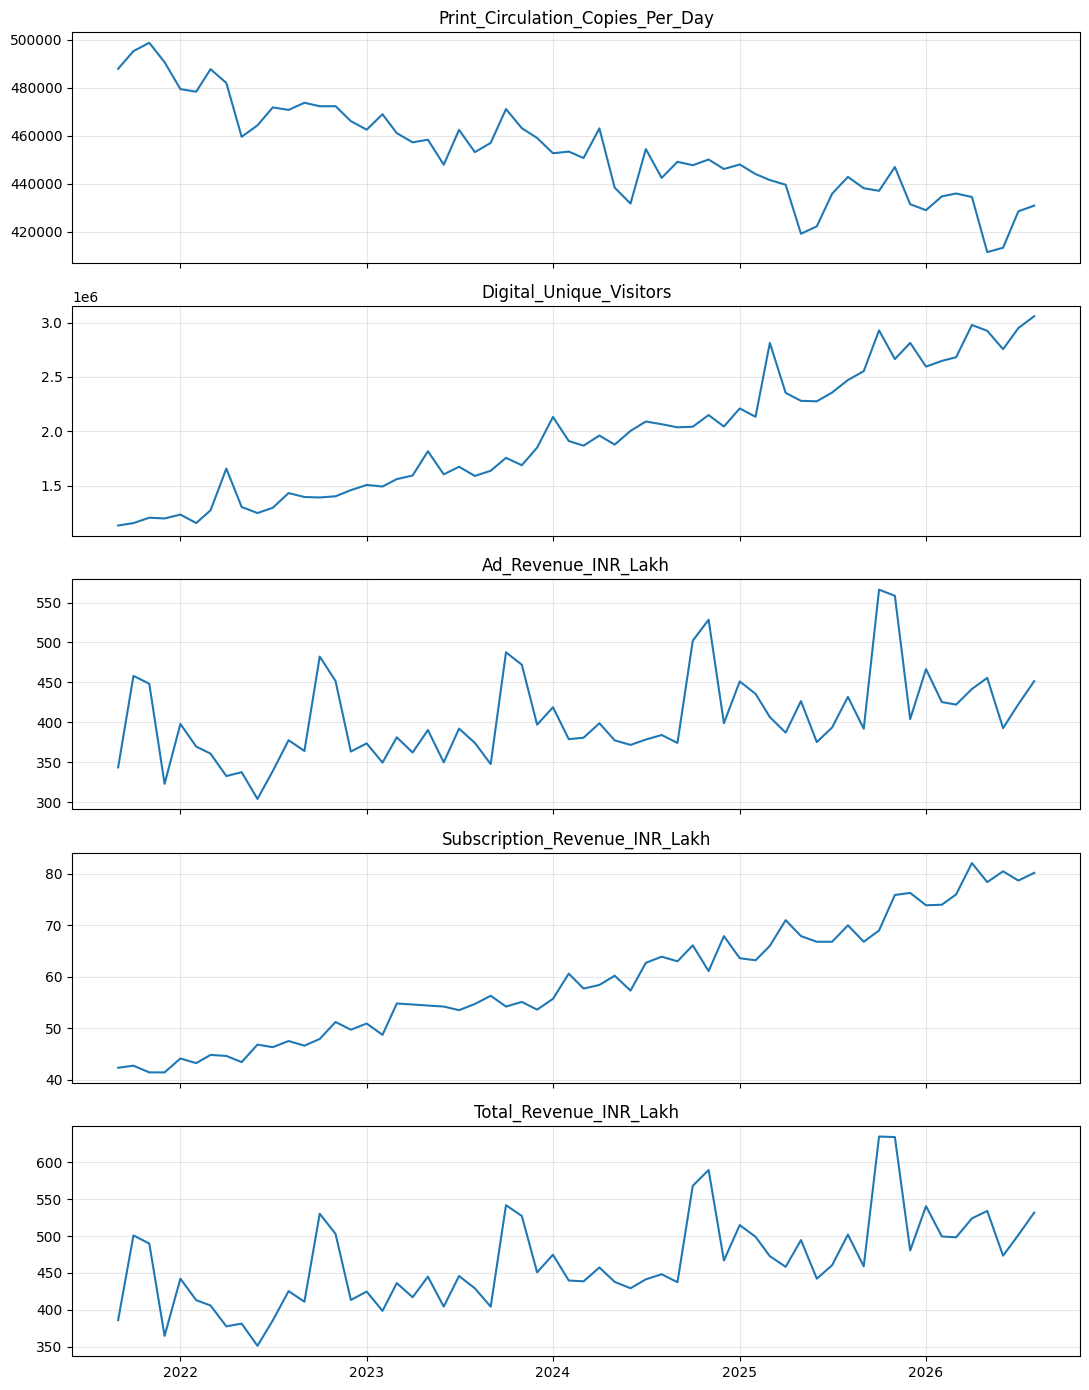

In [4]:
fig, axes = plt.subplots(len(METRICS), 1, figsize=(11, 14), sharex=True)
for ax, col in zip(axes, METRICS):
    ax.plot(df.index, df[col])
    ax.set_title(col)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Train / test split

We hold out the **last 12 months** as a test set to evaluate forecast accuracy honestly (no shuffling — this is a time series).

In [5]:
HORIZON = 12  # months to hold out for testing, and later to forecast forward

train = df.iloc[:-HORIZON]
test = df.iloc[-HORIZON:]

print("Train:", train.index.min().date(), "->", train.index.max().date(), f"({len(train)} months)")
print("Test :", test.index.min().date(), "->", test.index.max().date(), f"({len(test)} months)")

Train: 2021-09-01 -> 2025-08-01 (48 months)
Test : 2025-09-01 -> 2026-08-01 (12 months)


In [6]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"model": label, "MAE": round(mae, 2), "RMSE": round(rmse, 2), "MAPE_%": round(mape, 2)}

results = []

## 4. Baseline model — Seasonal naive

Forecast = value from the same month one year earlier. Any real model should beat this.

In [7]:
TARGET = "Total_Revenue_INR_Lakh"

seasonal_naive_pred = df[TARGET].shift(12).loc[test.index]
results.append(evaluate(test[TARGET], seasonal_naive_pred, "Seasonal Naive"))
pd.DataFrame(results)

,model,MAE,RMSE,MAPE_%
0,Seasonal Naive,33.79,38.56,6.28


## 5. SARIMA (statistical time-series model)

`SARIMAX(order=(1,1,1), seasonal_order=(1,1,1,12))` — a standard starting configuration for monthly data with yearly seasonality.

In [8]:
sarima_model = SARIMAX(
    train[TARGET],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)

sarima_pred = sarima_fit.get_forecast(steps=HORIZON).predicted_mean
sarima_pred.index = test.index

results.append(evaluate(test[TARGET], sarima_pred, "SARIMA"))
pd.DataFrame(results)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


,model,MAE,RMSE,MAPE_%
0,Seasonal Naive,33.79,38.56,6.28
1,SARIMA,15.90,20.28,2.86


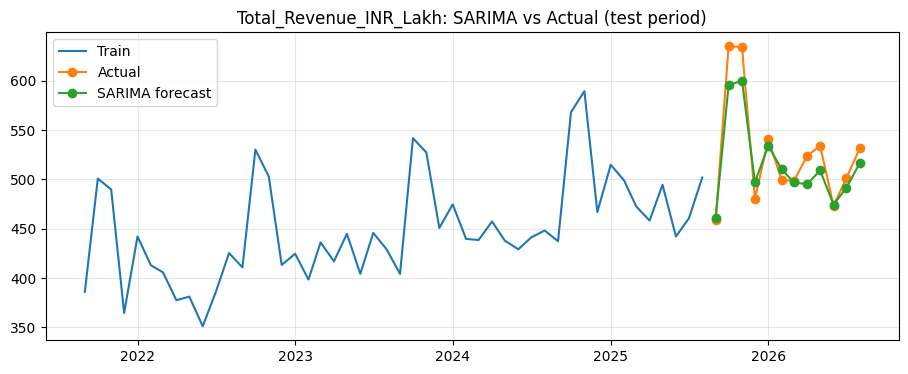

In [9]:
plt.plot(train.index, train[TARGET], label="Train")
plt.plot(test.index, test[TARGET], label="Actual", marker="o")
plt.plot(test.index, sarima_pred, label="SARIMA forecast", marker="o")
plt.title(f"{TARGET}: SARIMA vs Actual (test period)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Machine learning model — Random Forest with lag features

Turn the series into a supervised learning problem: predict month *t* from lagged values (t-1, t-2, t-3, t-12), a rolling mean, and calendar features (month, quarter).

In [10]:
def make_features(series, lags=(1, 2, 3, 12), roll_window=3):
    feat = pd.DataFrame({"y": series})
    for lag in lags:
        feat[f"lag_{lag}"] = series.shift(lag)
    feat[f"roll_mean_{roll_window}"] = series.shift(1).rolling(roll_window).mean()
    feat["month"] = feat.index.month
    feat["quarter"] = feat.index.quarter
    return feat.dropna()

feat_df = make_features(df[TARGET])
feat_train = feat_df.loc[feat_df.index.isin(train.index)]
feat_test = feat_df.loc[feat_df.index.isin(test.index)]

FEATURE_COLS = [c for c in feat_df.columns if c != "y"]

rf = RandomForestRegressor(n_estimators=400, max_depth=6, random_state=42)
rf.fit(feat_train[FEATURE_COLS], feat_train["y"])

rf_pred = pd.Series(rf.predict(feat_test[FEATURE_COLS]), index=feat_test.index)
results.append(evaluate(feat_test["y"], rf_pred, "Random Forest (lag features)"))
pd.DataFrame(results).sort_values("MAPE_%")

,model,MAE,RMSE,MAPE_%
1,SARIMA,15.90,20.28,2.86
2,Random Forest (lag features),25.50,36.63,4.55
0,Seasonal Naive,33.79,38.56,6.28


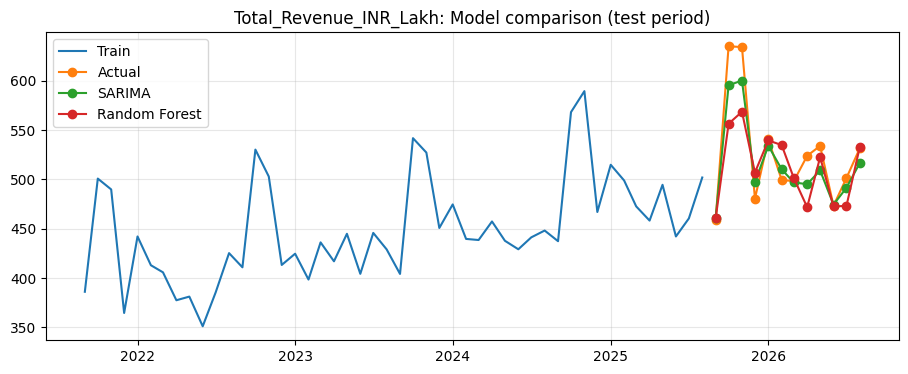

In [11]:
plt.plot(train.index, train[TARGET], label="Train")
plt.plot(test.index, test[TARGET], label="Actual", marker="o")
plt.plot(sarima_pred.index, sarima_pred, label="SARIMA", marker="o")
plt.plot(rf_pred.index, rf_pred, label="Random Forest", marker="o")
plt.title(f"{TARGET}: Model comparison (test period)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Forecast all 5 metrics, 12 months into the future

SARIMA generalizes cleanly to every metric without hand-built lag features, so we use it for the forward-looking forecast (refit on the **full** history for each metric) and save one fitted model per metric.

In [12]:
FUTURE_HORIZON = 12
future_index = pd.date_range(df.index.max() + pd.offsets.MonthBegin(1), periods=FUTURE_HORIZON, freq="MS")

fitted_models = {}
forecast_frames = []

for col in METRICS:
    model = SARIMAX(
        df[col],
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

    fitted_models[col] = model

    fc = model.get_forecast(steps=FUTURE_HORIZON)
    mean = fc.predicted_mean
    ci = fc.conf_int(alpha=0.2)  # 80% interval

    frame = pd.DataFrame({
        "Month": future_index,
        "metric": col,
        "forecast": mean.values,
        "lower_80": ci.iloc[:, 0].values,
        "upper_80": ci.iloc[:, 1].values,
    })
    forecast_frames.append(frame)

forecast_long = pd.concat(forecast_frames, ignore_index=True)
forecast_long.head(15)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,Month,metric,forecast,lower_80,upper_80
0,2026-09-01,Print_Circulation_Copies_Per_Day,4.285387e+05,-6.288974e+05,1.485975e+06
1,2026-10-01,Print_Circulation_Copies_Per_Day,4.273913e+05,-6.670910e+05,1.521874e+06
2,2026-11-01,Print_Circulation_Copies_Per_Day,4.358159e+05,-6.761881e+05,1.547820e+06
3,2026-12-01,Print_Circulation_Copies_Per_Day,4.226005e+05,-7.050412e+05,1.550242e+06
4,2027-01-01,Print_Circulation_Copies_Per_Day,4.210048e+05,-7.218895e+05,1.563899e+06
5,2027-02-01,Print_Circulation_Copies_Per_Day,4.248004e+05,-7.331271e+05,1.582728e+06
6,2027-03-01,Print_Circulation_Copies_Per_Day,4.252729e+05,-7.474930e+05,1.598039e+06
7,2027-04-01,Print_Circulation_Copies_Per_Day,4.237045e+05,-7.637142e+05,1.611123e+06
8,2027-05-01,Print_Circulation_Copies_Per_Day,4.012820e+05,-8.006108e+05,1.603175e+06
9,2027-06-01,Print_Circulation_Copies_Per_Day,4.033479e+05,-8.128467e+05,1.619542e+06


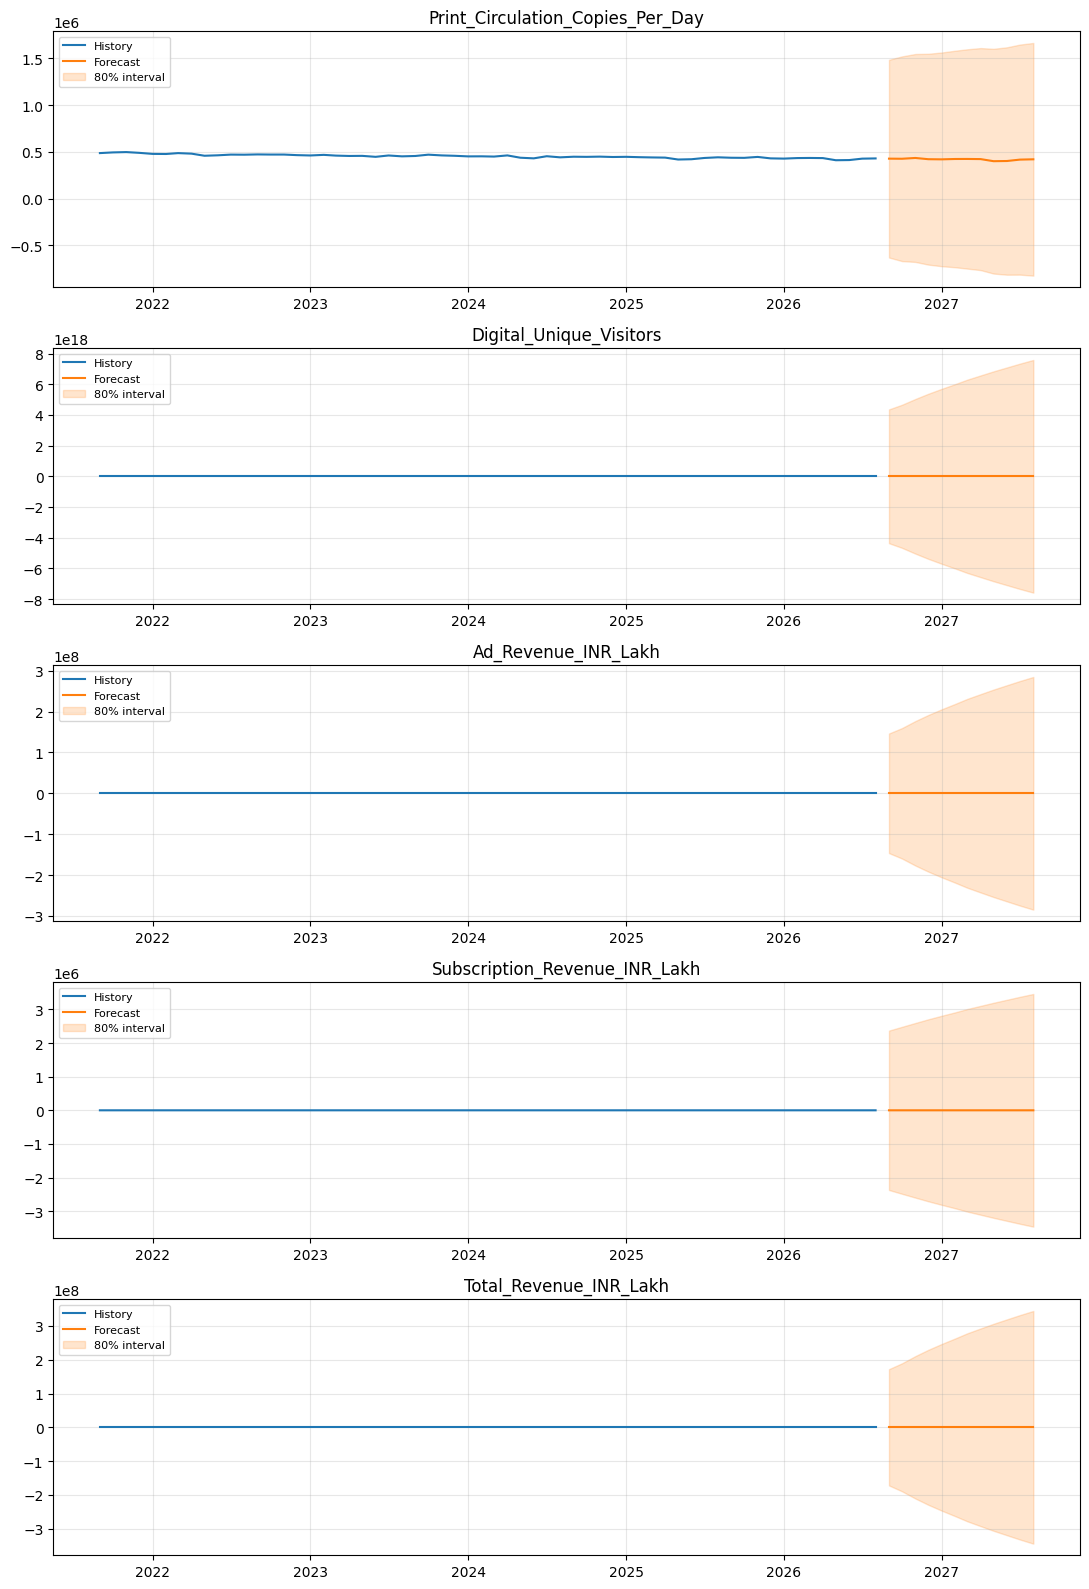

In [13]:
fig, axes = plt.subplots(len(METRICS), 1, figsize=(11, 16), sharex=False)
for ax, col in zip(axes, METRICS):
    hist = df[col]
    sub = forecast_long[forecast_long["metric"] == col]
    ax.plot(hist.index, hist.values, label="History")
    ax.plot(sub["Month"], sub["forecast"], label="Forecast", color="tab:orange")
    ax.fill_between(sub["Month"], sub["lower_80"], sub["upper_80"], color="tab:orange", alpha=0.2, label="80% interval")
    ax.set_title(col)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Save artifacts for the Streamlit app

In [14]:
import os
os.makedirs("models", exist_ok=True)

for col, model in fitted_models.items():
    joblib.dump(model, f"models/sarima_{col}.joblib")

forecast_wide = forecast_long.pivot(index="Month", columns="metric", values="forecast").reset_index()
forecast_wide.to_csv("tribune_trust_forecast_12m.csv", index=False)

metrics_table = pd.DataFrame(results)
metrics_table.to_csv("model_comparison_metrics.csv", index=False)

print("Saved:")
print(" - models/sarima_<metric>.joblib  (one SARIMA model per metric, fit on full history)")
print(" - tribune_trust_forecast_12m.csv (12-month forward forecast, wide format)")
print(" - model_comparison_metrics.csv   (baseline vs SARIMA vs RF accuracy on test set)")
metrics_table.sort_values("MAPE_%")

Saved:
 - models/sarima_<metric>.joblib  (one SARIMA model per metric, fit on full history)
 - tribune_trust_forecast_12m.csv (12-month forward forecast, wide format)
 - model_comparison_metrics.csv   (baseline vs SARIMA vs RF accuracy on test set)


,model,MAE,RMSE,MAPE_%
1,SARIMA,15.90,20.28,2.86
2,Random Forest (lag features),25.50,36.63,4.55
0,Seasonal Naive,33.79,38.56,6.28


## Notes / next steps
- SARIMA(1,1,1)(1,1,1,12) is a reasonable default; for production, grid-search orders (e.g. with `pmdarima.auto_arima`) per metric.
- The Random Forest step demonstrates a feature-engineered ML alternative — extend it with more lags/exogenous features (e.g. holidays, ad campaigns) and it can outperform SARIMA once real data is available.
- The saved `.joblib` models and `tribune_trust_forecast_12m.csv` are what `streamlit_app.py` reads to power the interactive forecasting dashboard.
- Swap in real Tribune Trust figures by replacing `tribune_trust_synthetic_data.csv` with the same column structure — no other code changes needed.